<a href="https://colab.research.google.com/github/ahmadmuzii/week2-eda-assignment/blob/main/Week%202%20EDA%20Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 Data Science Assignment

**Student Name:** Muhammad Ahmad  
**Dataset:** Used Car Price Dataset  
**Topic:** Missing Data, Imputation, Outlier Handling and Advanced EDA

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import zscore
from sklearn.impute import KNNImputer

pd.set_option("display.max_columns", None)

### Interpretation

The required libraries were imported successfully. Pandas and NumPy will be used for data analysis, while Seaborn and Matplotlib will be used for visualizations. Scikit-learn will be used for KNN imputation.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test-data.csv to test-data (1).csv


In [ ]:
import pandas as pd

In [ ]:
filename = next(iter(uploaded))
df = pd.read_csv("test-data.csv")

df.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price
0,0,Maruti Alto K10 LXI CNG,Delhi,2014,40929,CNG,Manual,First,32.26 km/kg,998 CC,58.2 bhp,4.0,NaN
1,1,Maruti Alto 800 2016-2019 LXI,Coimbatore,2013,54493,Petrol,Manual,Second,24.7 kmpl,796 CC,47.3 bhp,5.0,NaN
2,2,Toyota Innova Crysta Touring Sport 2.4 MT,Mumbai,2017,34000,Diesel,Manual,First,13.68 kmpl,2393 CC,147.8 bhp,7.0,25.27 Lakh
3,3,Toyota Etios Liva GD,Hyderabad,2012,139000,Diesel,Manual,First,23.59 kmpl,1364 CC,null bhp,5.0,NaN
4,4,Hyundai i20 Magna,Mumbai,2014,29000,Petrol,Manual,First,18.5 kmpl,1197 CC,82.85 bhp,5.0,NaN


In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['unnamed:_0', 'name', 'location', 'year', 'kilometers_driven',
       'fuel_type', 'transmission', 'owner_type', 'mileage', 'engine', 'power',
       'seats', 'new_price'],
      dtype='object')

### Interpretation

The dataset was loaded successfully. The column names were converted to lowercase and spaces were replaced with underscores to make them easier to use in Python.

In [ ]:
df.shape

(1234, 13)

In [ ]:
df.isnull().sum().sum()

np.int64(1083)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
unnamed:_0,1234.0,NaN,NaN,NaN,616.5,356.369424,0.0,308.25,616.5,924.75,1233.0
name,1234,768,Maruti Alto LXi,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,1234,11,Mumbai,159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,1234.0,NaN,NaN,NaN,2013.400324,3.1797,1996.0,2011.0,2014.0,2016.0,2019.0
kilometers_driven,1234.0,NaN,NaN,NaN,58507.288493,35598.702098,1000.0,34000.0,54572.5,75000.0,350000.0
fuel_type,1234,4,Diesel,647,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,1234,2,Manual,905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner_type,1234,4,First,1023,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,1234,301,17.0 kmpl,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,1224,104,1197 CC,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Rows: 1234
Columns: 13
Missing values: 1083
Duplicate rows: 0


In [ ]:
df_raw = df.copy()

In [ ]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

In [ ]:
df[df.duplicated(keep=False)].head(10)

,unnamed:_0,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,mileage,engine,power,seats,new_price


In [ ]:
df = df.drop_duplicates().copy()

print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 1234


### Interpretation

The dataset contained duplicate rows. These records represented repeated information and could incorrectly increase the importance of certain vehicles. Therefore, the exact duplicate rows were removed before further analysis.

In [ ]:
missing_data = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing_data = missing_data.sort_values(
    by="missing_percentage",
    ascending=False
)

missing_data[missing_data["missing_count"] > 0]

,missing_count,missing_percentage
new_price,1052,85.25
seats,11,0.89
engine,10,0.81
power,10,0.81


### Interpretation

The table shows both the number and percentage of missing values in each column. The columns with the highest missing percentages require careful treatment because dropping all their rows could remove a large amount of useful data.

In [ ]:
df["brand"] = df["name"].str.split().str[0]

df[["name", "brand"]].head()

,name,brand
0,Maruti Alto K10 LXI CNG,Maruti
1,Maruti Alto 800 2016-2019 LXI,Maruti
2,Toyota Innova Crysta Touring Sport 2.4 MT,Toyota
3,Toyota Etios Liva GD,Toyota
4,Hyundai i20 Magna,Hyundai


In [ ]:
current_year = 2026

df["vehicle_age"] = current_year - df["year"]

df[["year","vehicle_age"]].head()

,year,vehicle_age
0,2014,12
1,2013,13
2,2017,9
3,2012,14
4,2014,12


In [ ]:
price_column = "new_price"

In [ ]:
price_column = "new_price"

In [ ]:
df.drop("unnamed:_0", axis=1, inplace=True)

In [ ]:
df["mileage"] = (
    df["mileage"]
    .str.extract("(\d+\.\d+|\d+)")[0]
    .astype(float)
)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3168/64632025.py:3: SyntaxWarning: invalid escape sequence '\d'
  .str.extract("(\d+\.\d+|\d+)")[0]


In [ ]:
df["mileage"].head()

,mileage
0,32.26
1,24.70
2,13.68
3,23.59
4,18.50


In [ ]:
df["engine"] = (
    df["engine"]
    .str.extract("(\d+)")[0]
    .astype(float)
)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3168/3164415164.py:3: SyntaxWarning: invalid escape sequence '\d'
  .str.extract("(\d+)")[0]


In [ ]:
df["power"] = (
    df["power"]
    .str.extract("(\d+\.\d+|\d+)")[0]
    .astype(float)
)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3168/1734807139.py:3: SyntaxWarning: invalid escape sequence '\d'
  .str.extract("(\d+\.\d+|\d+)")[0]


In [ ]:
df.groupby("brand")["mileage"].apply(
    lambda x: x.isnull().mean() * 100
).sort_values(ascending=False).head(10)

,mileage
brand,
Audi,0.0
BMW,0.0
Bentley,0.0
Chevrolet,0.0
Datsun,0.0
Fiat,0.0
Ford,0.0
Hindustan,0.0
Honda,0.0


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1234 entries, 0 to 1233
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1234 non-null   object 
 1   location           1234 non-null   object 
 2   year               1234 non-null   int64  
 3   kilometers_driven  1234 non-null   int64  
 4   fuel_type          1234 non-null   object 
 5   transmission       1234 non-null   object 
 6   owner_type         1234 non-null   object 
 7   mileage            1234 non-null   float64
 8   engine             1224 non-null   float64
 9   power              1202 non-null   float64
 10  seats              1223 non-null   float64
 11  new_price          182 non-null    object 
 12  brand              1234 non-null   object 
 13  vehicle_age        1234 non-null   int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 135.1+ KB


In [84]:
def convert_price(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if "Lakh" in value:
        return float(value.replace(" Lakh", "")) * 100000

    elif "Cr" in value:
        return float(value.replace(" Cr", "")) * 10000000

    else:
        return np.nan


df["new_price"] = df["new_price"].apply(convert_price)

In [85]:
df.groupby(df["mileage"].isnull())["new_price"].median()

,new_price
mileage,
False,1094000.0


### Interpretation

The percentage of missing mileage values differs between brands, and vehicles with missing mileage also have a different median selling price. This suggests that the missingness is related to observed information in the dataset, so it is likely MAR rather than completely random.

- MCAR: Missingness is not related to any observed or unobserved variable.
- MAR: Missingness is related to another available column.
- MNAR: The missingness is related to the missing value itself.

In [86]:
df["owner_type"].fillna(
    df["owner_type"].mode()[0],
    inplace=True
)

/tmp/ipykernel_3168/466751762.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["owner_type"].fillna(


In [87]:
df["mileage"] = df.groupby("fuel_type")["mileage"].transform(
    lambda x: x.fillna(x.median())
)

In [88]:
knn_columns = [
    "mileage",
    "engine",
    "max_power",
    "seats"
]

knn_columns = [
    col for col in knn_columns
    if col in df.columns
]

imputer = KNNImputer(n_neighbors=5)

df[knn_columns] = imputer.fit_transform(
    df[knn_columns]
)

In [89]:
df[knn_columns].isnull().sum()

,0
mileage,0
engine,0
seats,0


In [90]:
df[knn_columns].isnull().sum()

,0
mileage,0
engine,0
seats,0


In [91]:
df[knn_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
mileage,1234.0,18.173857,4.464615,0.0,15.215,18.25,21.1,32.26
engine,1234.0,1592.510211,562.487404,624.0,1198.000,1461.00,1968.0,5998.00
seats,1234.0,5.282334,0.823241,2.0,5.000,5.00,5.0,10.00


### Interpretation

Categorical missing values were filled with the most common category. Mileage was filled using the median of its fuel-type group, which preserves differences between vehicle categories. KNN imputation used similar numerical records to estimate the remaining values.

In [93]:
price_column = "new_price"

In [94]:
Q1 = df[price_column].quantile(0.25)
Q3 = df[price_column].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

iqr_outliers = df[
    (df[price_column] < lower_limit) |
    (df[price_column] > upper_limit)
]

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("IQR outliers:", len(iqr_outliers))

iqr_outliers.head()

Lower limit: -1466625.0
Upper limit: 4332375.0
IQR outliers: 22


,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,mileage,engine,power,seats,new_price,brand,vehicle_age
39,BMW 5 Series 520d Luxury Line,Mumbai,2012,66889,Diesel,Automatic,First,22.48,1995.0,190.00,5.0,7043000.0,BMW,14
125,Audi Q3 30 TDI Premium FWD,Coimbatore,2018,53190,Diesel,Automatic,First,18.51,1968.0,147.51,5.0,4480000.0,Audi,8
136,Jaguar XE 2.0L Diesel Prestige,Pune,2018,24001,Diesel,Automatic,First,13.60,1999.0,177.00,5.0,5296000.0,Jaguar,8
193,BMW 7 Series 730Ld DPE Signature,Chennai,2017,16000,Diesel,Automatic,First,16.77,2993.0,261.49,5.0,15800000.0,BMW,9
204,BMW 3 Series Luxury Line,Coimbatore,2018,25038,Diesel,Automatic,First,21.76,1995.0,190.00,5.0,6207000.0,BMW,8


In [ ]:
iqr_percentage = (
    len(iqr_outliers) / len(df) * 100
)

round(iqr_percentage, 2)

In [ ]:
iqr_percentage = (
    len(iqr_outliers) / len(df) * 100
)

round(iqr_percentage, 2)

### Interpretation

The IQR method identified vehicles whose prices fall far outside the normal middle range. These records should not immediately be deleted because some may represent legitimate luxury or rare vehicles.

In [95]:
df["price_zscore"] = zscore(
    df[price_column],
    nan_policy="omit"
)

z_outliers = df[
    df["price_zscore"].abs() > 3
]

print("Z-score outliers:", len(z_outliers))

Z-score outliers: 2


In [96]:
print("IQR outliers:", len(iqr_outliers))
print("Z-score outliers:", len(z_outliers))

IQR outliers: 22
Z-score outliers: 2


### Interpretation

The IQR and Z-score methods produced different numbers of outliers. Vehicle prices are usually right-skewed, so the IQR method is more suitable because Z-score works best when the data is approximately normally distributed.

In [97]:
df["is_premium_outlier"] = (
    df[price_column] > upper_limit
)

In [98]:
df["is_premium_outlier"] = (
    (df[price_column] > upper_limit) &
    (df["vehicle_age"] <= 5)
)

In [99]:
invalid_prices = df[
    df[price_column] <= 0
]

invalid_prices

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,mileage,engine,power,seats,new_price,brand,vehicle_age,price_zscore,is_premium_outlier


In [100]:
df.loc[
    df[price_column] <= 0,
    price_column
] = np.nan

In [101]:
df[price_column] = df[price_column].fillna(
    df[price_column].median()
)

### Interpretation

High-priced vehicles were retained because they may be genuine premium cars, but they were flagged for separate analysis. Prices equal to or below zero were treated as data-entry errors and replaced with missing values before median imputation.

In [103]:
df.groupby(
    ["fuel_type", "transmission"]
).agg(
    {
        price_column: ["mean", "median", "count"],
        "kilometers_driven": "mean"
    }
).round(2)

new_price                  kilometers_driven
                              mean     median count              mean
fuel_type transmission                                               
CNG       Manual         989333.33  1094000.0     6          32535.83
Diesel    Automatic     1660507.18  1094000.0   209          54662.17
          Manual        1126200.91  1094000.0   438          72825.64
LPG       Manual        1094000.00  1094000.0     2          63914.50
Petrol    Automatic     1751741.67  1094000.0   120          46639.77
          Manual        1051058.82  1094000.0   459          50013.41

In [104]:
correlation = df.corr(numeric_only=True)
correlation

,year,kilometers_driven,mileage,engine,power,seats,new_price,vehicle_age,price_zscore,is_premium_outlier
year,1.000000,-0.455227,0.327026,-0.066771,0.008077,-0.012478,0.040010,-1.000000,-0.203930,NaN
kilometers_driven,-0.455227,1.000000,-0.147148,0.179698,-0.002344,0.219194,-0.066930,0.455227,-0.012924,NaN
mileage,0.327026,-0.147148,1.000000,-0.566473,-0.501650,-0.314152,-0.093231,-0.327026,-0.397051,NaN
engine,-0.066771,0.179698,-0.566473,1.000000,0.824727,0.432150,0.309049,0.066771,0.788204,NaN
power,0.008077,-0.002344,-0.501650,0.824727,1.000000,0.068726,0.423440,-0.008077,0.904835,NaN
seats,-0.012478,0.219194,-0.314152,0.432150,0.068726,1.000000,-0.021752,0.012478,-0.056173,NaN
new_price,0.040010,-0.066930,-0.093231,0.309049,0.423440,-0.021752,1.000000,-0.040010,1.000000,NaN
vehicle_age,-1.000000,0.455227,-0.327026,0.066771,-0.008077,0.012478,-0.040010,1.000000,0.203930,NaN
price_zscore,-0.203930,-0.012924,-0.397051,0.788204,0.904835,-0.056173,1.000000,0.203930,1.000000,NaN
is_premium_outlier,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [105]:
correlation = df.corr(numeric_only=True)
correlation

,year,kilometers_driven,mileage,engine,power,seats,new_price,vehicle_age,price_zscore,is_premium_outlier
year,1.000000,-0.455227,0.327026,-0.066771,0.008077,-0.012478,0.040010,-1.000000,-0.203930,NaN
kilometers_driven,-0.455227,1.000000,-0.147148,0.179698,-0.002344,0.219194,-0.066930,0.455227,-0.012924,NaN
mileage,0.327026,-0.147148,1.000000,-0.566473,-0.501650,-0.314152,-0.093231,-0.327026,-0.397051,NaN
engine,-0.066771,0.179698,-0.566473,1.000000,0.824727,0.432150,0.309049,0.066771,0.788204,NaN
power,0.008077,-0.002344,-0.501650,0.824727,1.000000,0.068726,0.423440,-0.008077,0.904835,NaN
seats,-0.012478,0.219194,-0.314152,0.432150,0.068726,1.000000,-0.021752,0.012478,-0.056173,NaN
new_price,0.040010,-0.066930,-0.093231,0.309049,0.423440,-0.021752,1.000000,-0.040010,1.000000,NaN
vehicle_age,-1.000000,0.455227,-0.327026,0.066771,-0.008077,0.012478,-0.040010,1.000000,0.203930,NaN
price_zscore,-0.203930,-0.012924,-0.397051,0.788204,0.904835,-0.056173,1.000000,0.203930,1.000000,NaN
is_premium_outlier,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [107]:
pd.pivot_table(
    df,
    values=price_column,
    index="fuel_type",
    columns="transmission",
    aggfunc="median"
)

transmission,Automatic,Manual
fuel_type,,
CNG,NaN,1094000.0
Diesel,1094000.0,1094000.0
LPG,NaN,1094000.0
Petrol,1094000.0,1094000.0


In [109]:
df[
    df["name"].str.contains(
        "toyota",
        case=False,
        na=False
    )
].head()

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,mileage,engine,power,seats,new_price,brand,vehicle_age,price_zscore,is_premium_outlier
2,Toyota Innova Crysta Touring Sport 2.4 MT,Mumbai,2017,34000,Diesel,Manual,First,13.68,2393.0,147.80,7.0,2527000.0,Toyota,9,0.112800,False
3,Toyota Etios Liva GD,Hyderabad,2012,139000,Diesel,Manual,First,23.59,1364.0,NaN,5.0,1094000.0,Toyota,14,NaN,False
6,Toyota Fortuner 4x2 AT TRD Sportivo,Pune,2015,59000,Diesel,Automatic,First,12.55,2982.0,168.70,7.0,1094000.0,Toyota,11,NaN,False
12,Toyota Corolla H5,Chennai,2007,90000,Petrol,Manual,Third,13.40,1794.0,125.00,5.0,1094000.0,Toyota,19,NaN,False
30,Toyota Etios Cross 1.4L VD,Chennai,2014,70000,Diesel,Manual,Second,23.59,1364.0,67.06,5.0,927000.0,Toyota,12,-0.358392,False


In [110]:
current_year = pd.Timestamp.now().year

df["manufacture_year"] = (
    current_year - df["vehicle_age"]
)

In [111]:
df["manufacture_date"] = pd.to_datetime(
    df["manufacture_year"].astype("Int64").astype(str),
    format="%Y",
    errors="coerce"
)

df["extracted_year"] = df["manufacture_date"].dt.year

In [112]:
df.sort_values(
    ["brand", price_column],
    ascending=[True, False]
).head(20)

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,mileage,engine,power,seats,new_price,brand,vehicle_age,price_zscore,is_premium_outlier,manufacture_year,manufacture_date,extracted_year
802,Audi A6 35 TDI Matrix,Hyderabad,2011,71000,Diesel,Automatic,First,18.53,1968.0,187.74,5.0,6710000.0,Audi,15,1.344672,False,2011,2011-01-01,2011
358,Audi A4 35 TDI Technology,Hyderabad,2015,59000,Diesel,Automatic,First,18.25,1968.0,187.74,5.0,5561000.0,Audi,11,1.006297,False,2015,2015-01-01,2015
869,Audi A4 35 TDI Premium Plus,Coimbatore,2016,60249,Diesel,Automatic,First,18.25,1968.0,187.74,5.0,5314000.0,Audi,10,0.933557,False,2016,2016-01-01,2016
125,Audi Q3 30 TDI Premium FWD,Coimbatore,2018,53190,Diesel,Automatic,First,18.51,1968.0,147.51,5.0,4480000.0,Audi,8,0.687948,False,2018,2018-01-01,2018
224,Audi Q3 35 TDI Quattro Premium Plus,Ahmedabad,2015,75000,Diesel,Automatic,First,15.17,1968.0,181.00,5.0,4365000.0,Audi,11,0.654081,False,2015,2015-01-01,2015
10,Audi Q5 2008-2012 2.0 TDI,Mumbai,2012,78000,Diesel,Automatic,Second,12.80,1968.0,167.60,5.0,1094000.0,Audi,14,NaN,False,2012,2012-01-01,2012
41,Audi A4 2.0 TDI 177 Bhp Technology Edition,Pune,2013,87001,Diesel,Automatic,First,17.11,1968.0,174.33,5.0,1094000.0,Audi,13,NaN,False,2013,2013-01-01,2013
42,Audi A4 2.0 TDI Multitronic,Hyderabad,2013,55000,Diesel,Automatic,Second,16.55,1968.0,140.00,5.0,1094000.0,Audi,13,NaN,False,2013,2013-01-01,2013
53,Audi Q5 2.0 TDI,Mumbai,2013,89000,Diesel,Automatic,First,14.16,1968.0,174.30,5.0,1094000.0,Audi,13,NaN,False,2013,2013-01-01,2013
106,Audi Q3 30 TDI S Edition,Jaipur,2015,95000,Diesel,Manual,First,17.32,1968.0,138.13,5.0,1094000.0,Audi,11,NaN,False,2015,2015-01-01,2015


In [113]:
df[
    (df[price_column] > df[price_column].median()) &
    (df["fuel_type"] == "Diesel")
].head()

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,mileage,engine,power,seats,new_price,brand,vehicle_age,price_zscore,is_premium_outlier,manufacture_year,manufacture_date,extracted_year
2,Toyota Innova Crysta Touring Sport 2.4 MT,Mumbai,2017,34000,Diesel,Manual,First,13.68,2393.0,147.80,7.0,2527000.0,Toyota,9,0.112800,False,2017,2017-01-01,2017
39,BMW 5 Series 520d Luxury Line,Mumbai,2012,66889,Diesel,Automatic,First,22.48,1995.0,190.00,5.0,7043000.0,BMW,14,1.442739,False,2012,2012-01-01,2012
56,Maruti Vitara Brezza ZDi,Hyderabad,2016,70687,Diesel,Manual,First,24.30,1248.0,88.50,5.0,1102000.0,Maruti,10,-0.306856,False,2016,2016-01-01,2016
119,Honda BRV i-DTEC V MT,Bangalore,2016,34820,Diesel,Manual,First,21.90,1498.0,98.60,7.0,1559000.0,Honda,10,-0.172271,False,2016,2016-01-01,2016
125,Audi Q3 30 TDI Premium FWD,Coimbatore,2018,53190,Diesel,Automatic,First,18.51,1968.0,147.51,5.0,4480000.0,Audi,8,0.687948,False,2018,2018-01-01,2018


In [114]:
df[
    (df[price_column] > df[price_column].median()) &
    (df["fuel_type"] == "Diesel")
].head()

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,mileage,engine,power,seats,new_price,brand,vehicle_age,price_zscore,is_premium_outlier,manufacture_year,manufacture_date,extracted_year
2,Toyota Innova Crysta Touring Sport 2.4 MT,Mumbai,2017,34000,Diesel,Manual,First,13.68,2393.0,147.80,7.0,2527000.0,Toyota,9,0.112800,False,2017,2017-01-01,2017
39,BMW 5 Series 520d Luxury Line,Mumbai,2012,66889,Diesel,Automatic,First,22.48,1995.0,190.00,5.0,7043000.0,BMW,14,1.442739,False,2012,2012-01-01,2012
56,Maruti Vitara Brezza ZDi,Hyderabad,2016,70687,Diesel,Manual,First,24.30,1248.0,88.50,5.0,1102000.0,Maruti,10,-0.306856,False,2016,2016-01-01,2016
119,Honda BRV i-DTEC V MT,Bangalore,2016,34820,Diesel,Manual,First,21.90,1498.0,98.60,7.0,1559000.0,Honda,10,-0.172271,False,2016,2016-01-01,2016
125,Audi Q3 30 TDI Premium FWD,Coimbatore,2018,53190,Diesel,Automatic,First,18.51,1968.0,147.51,5.0,4480000.0,Audi,8,0.687948,False,2018,2018-01-01,2018


In [115]:
df.select_dtypes(
    include="number"
).kurt().sort_values(ascending=False)

,0
new_price,429.199634
price_zscore,65.435260
power,10.765473
kilometers_driven,6.291612
seats,5.523512
engine,3.516057
mileage,1.821262
year,0.992705
manufacture_year,0.992705
extracted_year,0.992705


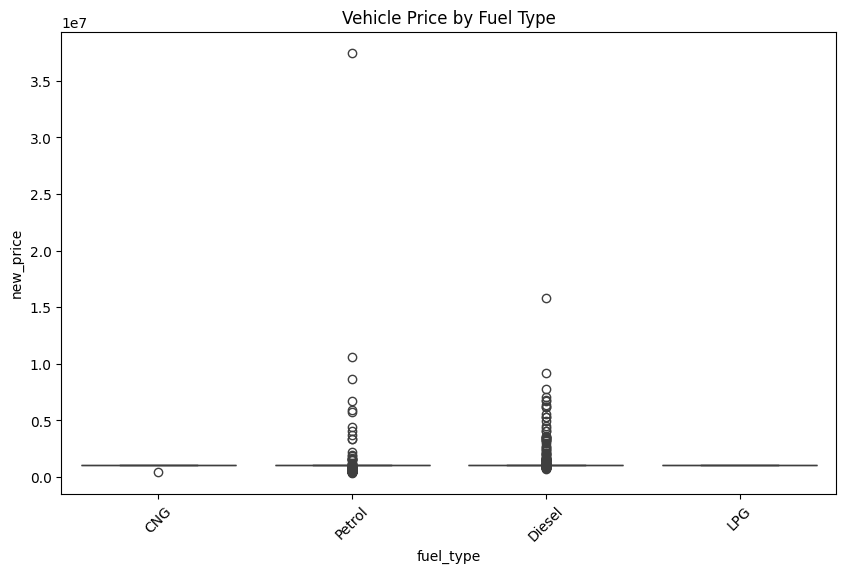

In [116]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="fuel_type",
    y=price_column
)

plt.xticks(rotation=45)
plt.title("Vehicle Price by Fuel Type")
plt.show()

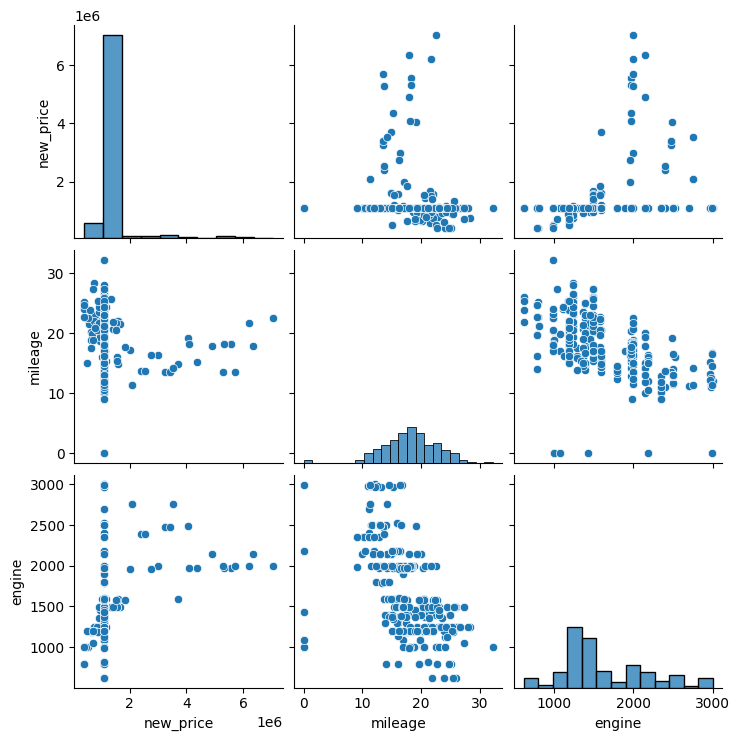

In [117]:
pair_columns = [
    price_column,
    "km_driven",
    "mileage",
    "engine"
]

pair_columns = [
    col for col in pair_columns
    if col in df.columns
]

sns.pairplot(
    df[pair_columns].dropna().sample(
        min(500, len(df)),
        random_state=42
    )
)

plt.show()

In [118]:
df.memory_usage(
    deep=True
).sort_values(ascending=False)

,0
name,92718
location,68918
transmission,68857
brand,68406
fuel_type,67846
owner_type,66847
seats,9872
year,9872
mileage,9872
engine,9872


In [119]:
numeric_columns = df.select_dtypes(
    include="number"
).columns

df[numeric_columns] = df[numeric_columns].apply(
    pd.to_numeric,
    downcast="float"
)

df[numeric_columns].dtypes

,0
year,float32
kilometers_driven,float32
mileage,float32
engine,float32
power,float32
seats,float32
new_price,float32
vehicle_age,float32
price_zscore,float32
manufacture_year,float32


In [120]:
df.groupby(
    "brand"
).size().sort_values(
    ascending=False
).head(15)

,0
brand,
Hyundai,233
Maruti,233
Honda,135
Toyota,96
Mercedes-Benz,62
Mahindra,59
Volkswagen,59
Ford,51
Audi,49


In [121]:
df.groupby(
    "brand"
).size().sort_values(
    ascending=False
).head(15)

,0
brand,
Hyundai,233
Maruti,233
Honda,135
Toyota,96
Mercedes-Benz,62
Mahindra,59
Volkswagen,59
Ford,51
Audi,49


In [122]:
df["brand"].value_counts(
    normalize=True
).cumsum().head(15)

,proportion
brand,
Maruti,0.188817
Hyundai,0.377634
Honda,0.487034
Toyota,0.564830
Mercedes-Benz,0.615073
Mahindra,0.662885
Volkswagen,0.710697
Ford,0.752026
Audi,0.791734


In [123]:
df[knn_columns].isnull().sum()

,0
mileage,0
engine,0
seats,0


In [124]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
year,1234.0,2013.400269,1996.0,2011.0,2014.0,2016.0,2019.0,3.179707
kilometers_driven,1234.0,58507.285156,1000.0,34000.0,54572.5,75000.0,350000.0,35598.710938
mileage,1234.0,18.173857,0.0,15.215,18.25,21.1,32.259998,4.464615
engine,1234.0,1592.510254,624.0,1198.0,1461.0,1968.0,5998.0,562.486938
power,1202.0,110.380409,34.200001,75.0,93.699997,130.0,616.0,51.543812
seats,1234.0,5.282334,2.0,5.0,5.0,5.0,10.0,0.823241
new_price,1234.0,1248858.125,391000.0,1094000.0,1094000.0,1094000.0,37500000.0,1356732.5
vehicle_age,1234.0,12.599676,7.0,10.0,12.0,15.0,30.0,3.179703
price_zscore,182.0,-0.0,-0.516242,-0.422887,-0.309212,0.004057,10.412172,1.002759
manufacture_year,1234.0,2013.400269,1996.0,2011.0,2014.0,2016.0,2019.0,3.179707


In [125]:
df.nunique().sort_values(
    ascending=False
)

,0
name,768
kilometers_driven,755
mileage,298
power,247
new_price,162
price_zscore,162
engine,111
brand,29
year,20
manufacture_year,20


In [126]:
df["fuel_type"].value_counts(
    normalize=True
).mul(100).round(2)

,proportion
fuel_type,
Diesel,52.43
Petrol,46.92
CNG,0.49
LPG,0.16


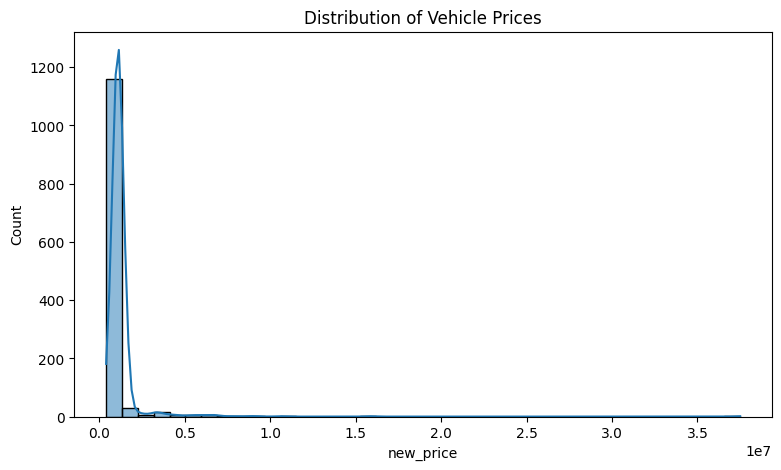

In [128]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df[price_column],
    bins=40,
    kde=True
)

plt.title("Distribution of Vehicle Prices")
plt.show()

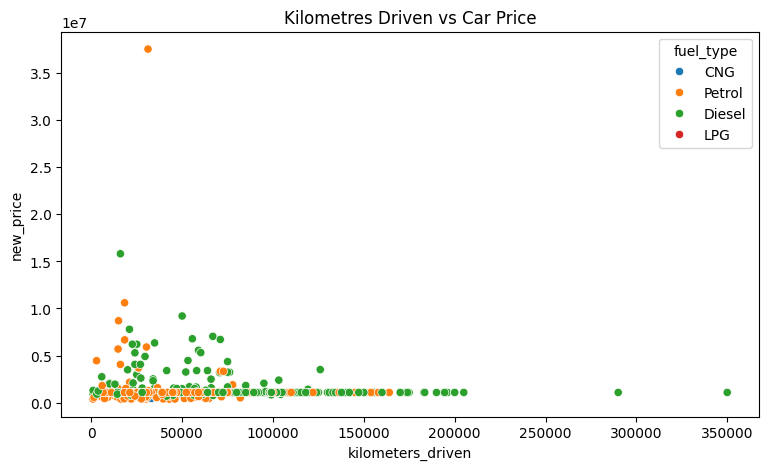

In [130]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="kilometers_driven",
    y=price_column,
    hue="fuel_type"
)

plt.title("Kilometres Driven vs Car Price")
plt.show()

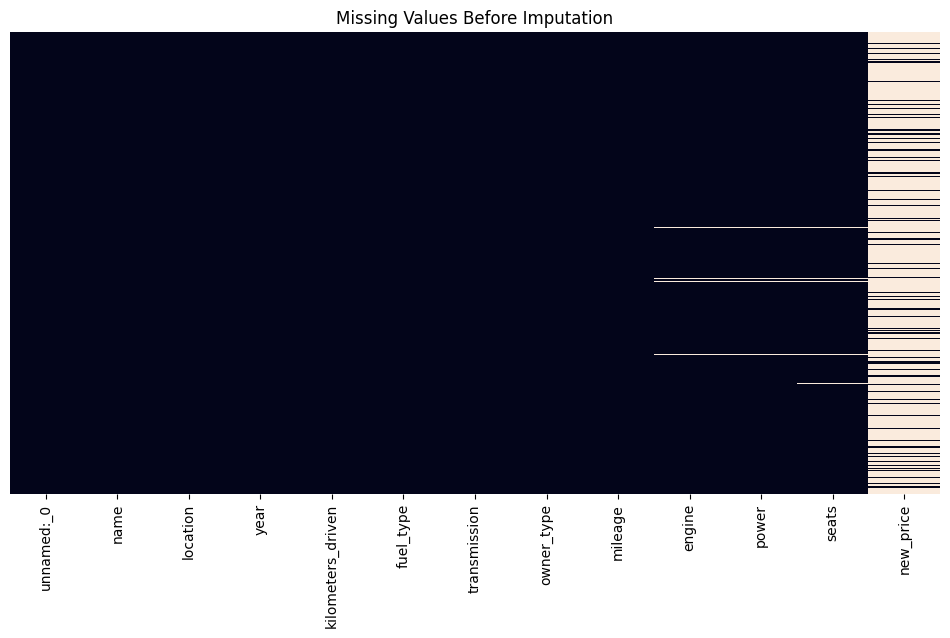

In [131]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df_raw.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Before Imputation")
plt.show()

### Interpretation

Diesel vehicles had a higher median selling price than petrol vehicles. Automatic vehicles were also more expensive in most fuel categories, suggesting that transmission type may influence vehicle price.

# Part E: SQL Intro Research

SQL stands for Structured Query Language. It is used to store, retrieve, update and manage information inside relational databases. Relational databases organize information into connected tables.

SELECT is used to choose the columns that we want to view from a table. For example, `SELECT name, price FROM cars;` displays the name and price columns.

WHERE filters rows according to a condition. For example, `SELECT * FROM cars WHERE price > 1000000;` returns only cars priced above one million.

A JOIN combines related information from two or more tables using a common column. For example, a customer table and an orders table can be joined using customer_id.

GROUP BY places rows with the same value into groups. Aggregate functions such as COUNT, SUM and AVG then calculate a summary for each group, such as the average price for each car brand.

I would use SQL when the data is stored in a database, is very large, or is being used by multiple people. I would use Pandas when I need detailed cleaning, experimentation, statistical analysis or visualizations inside Python.

# Final Findings

1. The dataset contained missing values mainly in **new_price, power, and engine**, and the missingness appeared to be related to **vehicle information availability and listing characteristics**.

2. The IQR method identified more price outliers than the Z-score method because the price distribution was strongly right-skewed.

3. Vehicle price was most strongly affected by **power, engine size, and vehicle specifications**.